### Linear Regression Implementation 1

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_1 = pd.read_csv('../DataSet/weight-height.csv')

In [3]:
df_1.head(5)

,Gender,Height,Weight
0,Male,69.179858,192.014335
1,Male,72.870360,211.342497
2,Male,64.782583,165.611626
3,Male,70.183550,201.071918
4,Male,68.491450,173.423960


In [4]:
df_1.isnull().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [5]:
df = df_1.drop('Gender', axis=1)

In [6]:
df.head(5)

,Height,Weight
0,69.179858,192.014335
1,72.870360,211.342497
2,64.782583,165.611626
3,70.183550,201.071918
4,68.491450,173.423960


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

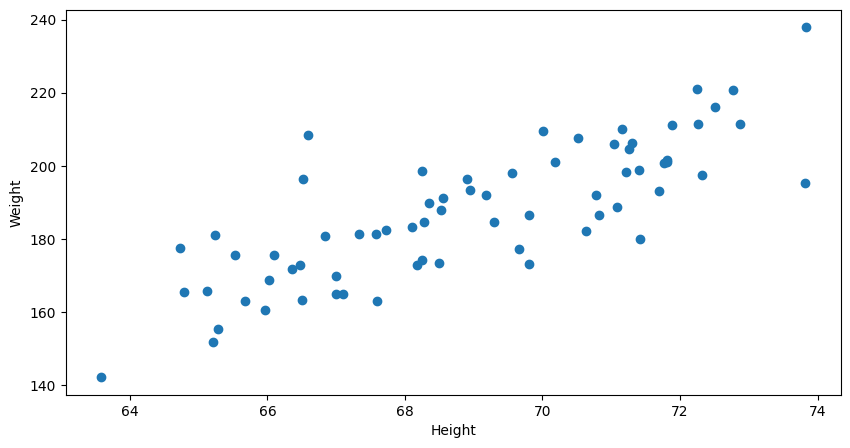

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [9]:
df.corr()

,Height,Weight
Height,1.000000,0.803286
Weight,0.803286,1.000000


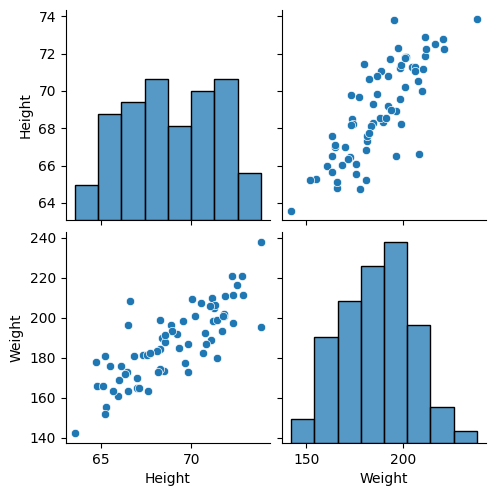

In [10]:
sns.pairplot(df)

In [11]:
X = df[['Height']]
X.head(5)

,Height
0,69.179858
1,72.870360
2,64.782583
3,70.183550
4,68.491450


In [12]:
y = df['Weight']
y.head()

0    192.014335
1    211.342497
2    165.611626
3    201.071918
4    173.423960
Name: Weight, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [15]:
X_train.shape

(51, 1)

In [16]:
X_test.shape

(18, 1)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [19]:
X_train

array([[ 1.00498853],
       [-0.73203234],
       [ 0.87566479],
       [ 1.77273694],
       [ 1.02356637],
       [ 1.0212438 ],
       [-0.9570776 ],
       [ 0.27498329],
       [-0.30693965],
       [-0.96761247],
       [-1.61567799],
       [ 1.37750872],
       [ 1.04715003],
       [-0.04349071],
       [-0.54882292],
       [-0.92106796],
       [ 0.18023884],
       [-0.83288257],
       [ 0.41554656],
       [-1.4117313 ],
       [-0.26647821],
       [-0.33092283],
       [-0.7739887 ],
       [-1.15826619],
       [-0.18998651],
       [-1.26303412],
       [-0.771776  ],
       [ 0.81400837],
       [ 1.21038509],
       [ 1.28165992],
       [ 0.98102156],
       [ 0.22186472],
       [-1.10806276],
       [-1.3211586 ],
       [ 0.35213738],
       [-0.55557235],
       [-2.04466394],
       [ 0.73642398],
       [ 0.7491895 ],
       [ 1.18368537],
       [-1.42747351],
       [ 1.19197497],
       [ 1.41662709],
       [-0.2034454 ],
       [-0.06391949],
       [-1

In [20]:
X_test = scaler.transform(X_test)

In [21]:
X_test

array([[ 0.08243559],
       [ 0.04158015],
       [-1.47202218],
       [-0.21491404],
       [-1.01230255],
       [-0.29586264],
       [ 0.80019944],
       [-0.30615467],
       [ 0.58581314],
       [ 0.86997023],
       [-1.13238745],
       [ 0.63571383],
       [ 0.65114683],
       [-0.64735003],
       [-1.43854052],
       [-0.95220495],
       [ 0.77694984],
       [ 0.27355763]])

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
regression = LinearRegression(n_jobs=-1)

In [24]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [25]:
print(f"COefficient or slop : {regression.coef_}")
print(f"Intercept : {regression.intercept_}")

COefficient or slop : [16.08340788]
Intercept : 188.653178240223


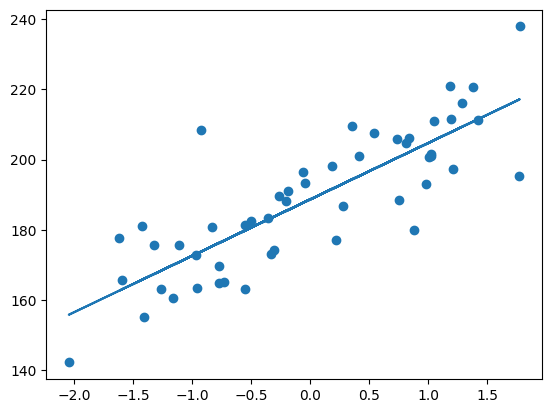

In [26]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

y_pred = intercept + coef_(weight)

    where weight is X_test

In [27]:
y_pred = regression.predict(X_test)

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [29]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [30]:
print(f"Mean squared error : {mse}")
print(f"Mean absolute error : {mae}")
print(f"Root mean squared error : {rmse}")

Mean squared error : 116.41352132304038
Mean absolute error : 8.327825092097756
Root mean squared error : 10.789509781405288


In [35]:
score = r2_score(y_test, y_pred)

In [37]:
print(f"R2 score {score}")

R2 score 0.4181260734107185


In [41]:
import statsmodels.api as sm

In [42]:
model = sm.OLS(y_train, X_train).fit()

In [43]:
prediction = model.predict(X_test)
print(prediction)

[  1.32584523   0.66875045 -23.67513317  -3.45655018 -16.28127475
  -4.75847957  12.86993391  -4.92401041   9.4218716   13.99208609
 -18.21264928  10.2244448   10.47266007 -10.41159463 -23.13663393
 -15.3147006   12.49600125   4.39973898]


In [44]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Weight   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):             -0.013
Method:                 Least Squares   F-statistic:                             0.3622
Date:                Thu, 31 Jul 2025   Prob (F-statistic):                       0.550
Time:                        20:01:46   Log-Likelihood:                         -339.69
No. Observations:                  51   AIC:                                      681.4
Df Residuals:                      50   BIC:                                      683.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [47]:
regression.predict(scaler.transform([[70]]))

c:\Users\ASUS\Desktop\projects\Macchine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([194.23665513])